### Load Packages

In [2]:
using LinearAlgebra
using Random
using JuMP, MosekTools, ECOS
using Statistics
using Printf
using PyPlot
using Colors
using Noise

### Include files

In [3]:
core_path = "../../src/core/"
module_path = "../../src/quad3dofcage/"

# Include base core files
include(core_path * "globals.jl")
include(core_path * "structs.jl")

# Include module files
include(module_path * "params.jl")
include(module_path * "scenarios.jl")
include(module_path * "plots.jl")
include(module_path * "opt_prob.jl")
include(module_path * "ddto_feas_prob.jl")
include(module_path * "ddtoscp_feas_prob.jl")

# Include utility files (dependent on module file definitions)
include(core_path * "utils.jl")
include(core_path * "utils_opt.jl")
include(core_path * "utils_ddto.jl")
include(core_path * "utils_ddtoscp.jl")
;

### Simulate scenario

Standard DDTO

In [4]:
# ..:: Setup ::..
params = Params()
scenario_toy1!(params)

# ..:: Execute solver sequence ::..
@time begin
    @time begin
        # ..:: Solve for independently-optimal solutions to each target ::..
        opt_solutions = solve_optimal_tree(params)
        opt_costs = CVector(zeros(params.n_targs))
        for k = 1:params.n_targs
            opt_costs[k] = opt_solutions[k].sol.cost
        end
        println("\n Solve time for generating optimal solutions to each target:")
    end

    @time begin
        # ..:: Solve for DDTO branching solutions to ALL targets ::..
        ddto_solutions = solve_ddto_tree(params, opt_costs)
        println("\n Solve time for generating DDTO branch solutions to all targets:")
    end
    println("\n Solve time for the full DDTO solution stack:")
end
branch_solutions = extract_target_trajectories(params, ddto_solutions)

# ..:: Simulate each target solution from I.C. to T.C.
@time begin
    x0 = vcat(params.r0, params.v0)
    dynamics = (t,x,sol) -> params.A_c*x + params.B_c*optimal_controller(t,x,sol) + params.p_c
    opt_simulations = simulate_cont(opt_solutions, x0, dynamics)
    branch_simulations = simulate_cont(branch_solutions, x0, dynamics)
    println("\n Solve time for RK4 simulation:")
end

# ..:: Post-processing ::..
@time begin
    branch_solutions   = process_solutions(branch_solutions)
    branch_simulations = process_solutions(branch_simulations)
    opt_solutions      = process_solutions(opt_solutions)
    opt_simulations    = process_solutions(opt_simulations)
    println("\n Solve time for post-processing:")
end
;


=== Optimal solutions for each target ===
Target: 1, Cost: 34.337
Target: 2, Cost: 34.344
Target: 3, Cost: 34.343
Target: 4, Cost: 34.337

 Solve time for generating optimal solutions to each target:
 10.033364 seconds (28.71 M allocations: 1.683 GiB, 4.61% gc time, 98.70% compilation time)

========= Solving DDTO for Branch #1 =========
=== Bisection Search for QCvx Optimization ===
Iteration: 1, τ_min: 10, τ_max: 19 -- Feasible
Iteration: 2, τ_min: 15, τ_max: 19 -- Feasible
Iteration: 3, τ_min: 17, τ_max: 19 -- Feasible
Iteration: 4, τ_min: 18, τ_max: 19 -- Feasible
Bisection search terminated -- reached convergence condition (τ_max - τ_min) = 1
Bisection search successful -- τ_opt: 18
New costs to each remaining target:
   Target: 1, Cost: 35.761
   Target: 2, Cost: 35.533
   Target: 3, Cost: 35.360
   Target: 4, Cost: 35.453
   Removed target 3 for next branch iteration

========= Solving DDTO for Branch #2 =========
=== Bisection Search for QCvx Optimization ===
Bisection search 

DDTO w/ Sequential Convex Programming (SCP)

In [5]:
# ..:: Setup ::..
params = Params()
scenario_toy1!(params)

# ..:: Execute solver sequence ::..
@time begin
    @time begin
        # ..:: Solve for independently-optimal solutions to each target ::..
        opt_solutions = solve_optimal_tree(params)
        opt_costs = CVector(zeros(params.n_targs))
        for k = 1:params.n_targs
            opt_costs[k] = opt_solutions[k].sol.cost
        end
        println("\n Solve time for generating optimal solutions to each target:")
    end

    # Port back to `Vector{Solution}` for type conformance
    opt_solutions_ = Vector{Solution}(undef,params.n_targs)
    for j=1:params.n_targs
        opt_solutions_[j] = opt_solutions[j].sol
    end

    @time begin
        # ..:: Solve for DDTO branching solutions to ALL targets ::..
        ddtoscp_solutions = solve_ddtoscp_tree(params, opt_costs, opt_solutions_)
        println("\n Solve time for generating DDTO branch solutions to all targets:")
    end
    println("\n Solve time for the full DDTO solution stack:")
end
branchscp_solutions = extract_target_trajectories(params, ddtoscp_solutions)

# ..:: Simulate each target solution from I.C. to T.C.
@time begin
    x0 = vcat(params.r0, params.v0)
    dynamics = (t,x,sol) -> params.A_c*x + params.B_c*optimal_controller(t,x,sol) + params.p_c
    opt_simulations = simulate_cont(opt_solutions, x0, dynamics)
    branchscp_simulations = simulate_cont(branchscp_solutions, x0, dynamics)
    println("\n Solve time for RK4 simulation:")
end

# ..:: Post-processing ::..
@time begin
    branchscp_solutions   = process_solutions(branchscp_solutions)
    branchscp_simulations = process_solutions(branchscp_simulations)
    opt_solutions      = process_solutions(opt_solutions)
    opt_simulations    = process_solutions(opt_simulations)
    println("\n Solve time for post-processing:")
end
;


=== Optimal solutions for each target ===
Target: 1, Cost: 34.337
Target: 2, Cost: 34.344
Target: 3, Cost: 34.343
Target: 4, Cost: 34.337

 Solve time for generating optimal solutions to each target:
  0.016772 seconds (88.63 k allocations: 5.562 MiB)

========= Solving DDTO for Branch #1 =========
   Chosen suboptimality tolerances: {0.200, 0.200, 0.200, 0.200}
=== Bisection Search for QCvx Optimization ===
MOSEK warning 705: #1 (nearly) zero elements are specified in sparse row ''(5409) of matrix 'A'.
MOSEK warning 705: #1 (nearly) zero elements are specified in sparse row ''(5410) of matrix 'A'.
MOSEK warning 705: #1 (nearly) zero elements are specified in sparse row ''(5411) of matrix 'A'.
MOSEK warning 705: #1 (nearly) zero elements are specified in sparse row ''(5412) of matrix 'A'.
MOSEK warning 705: #1 (nearly) zero elements are specified in sparse row ''(5413) of matrix 'A'.
MOSEK warning 705: #1 (nearly) zero elements are specified in sparse row ''(5414) of matrix 'A'.
MOSEK

### Plotting

In [6]:
set_fonts()
set_fonts()

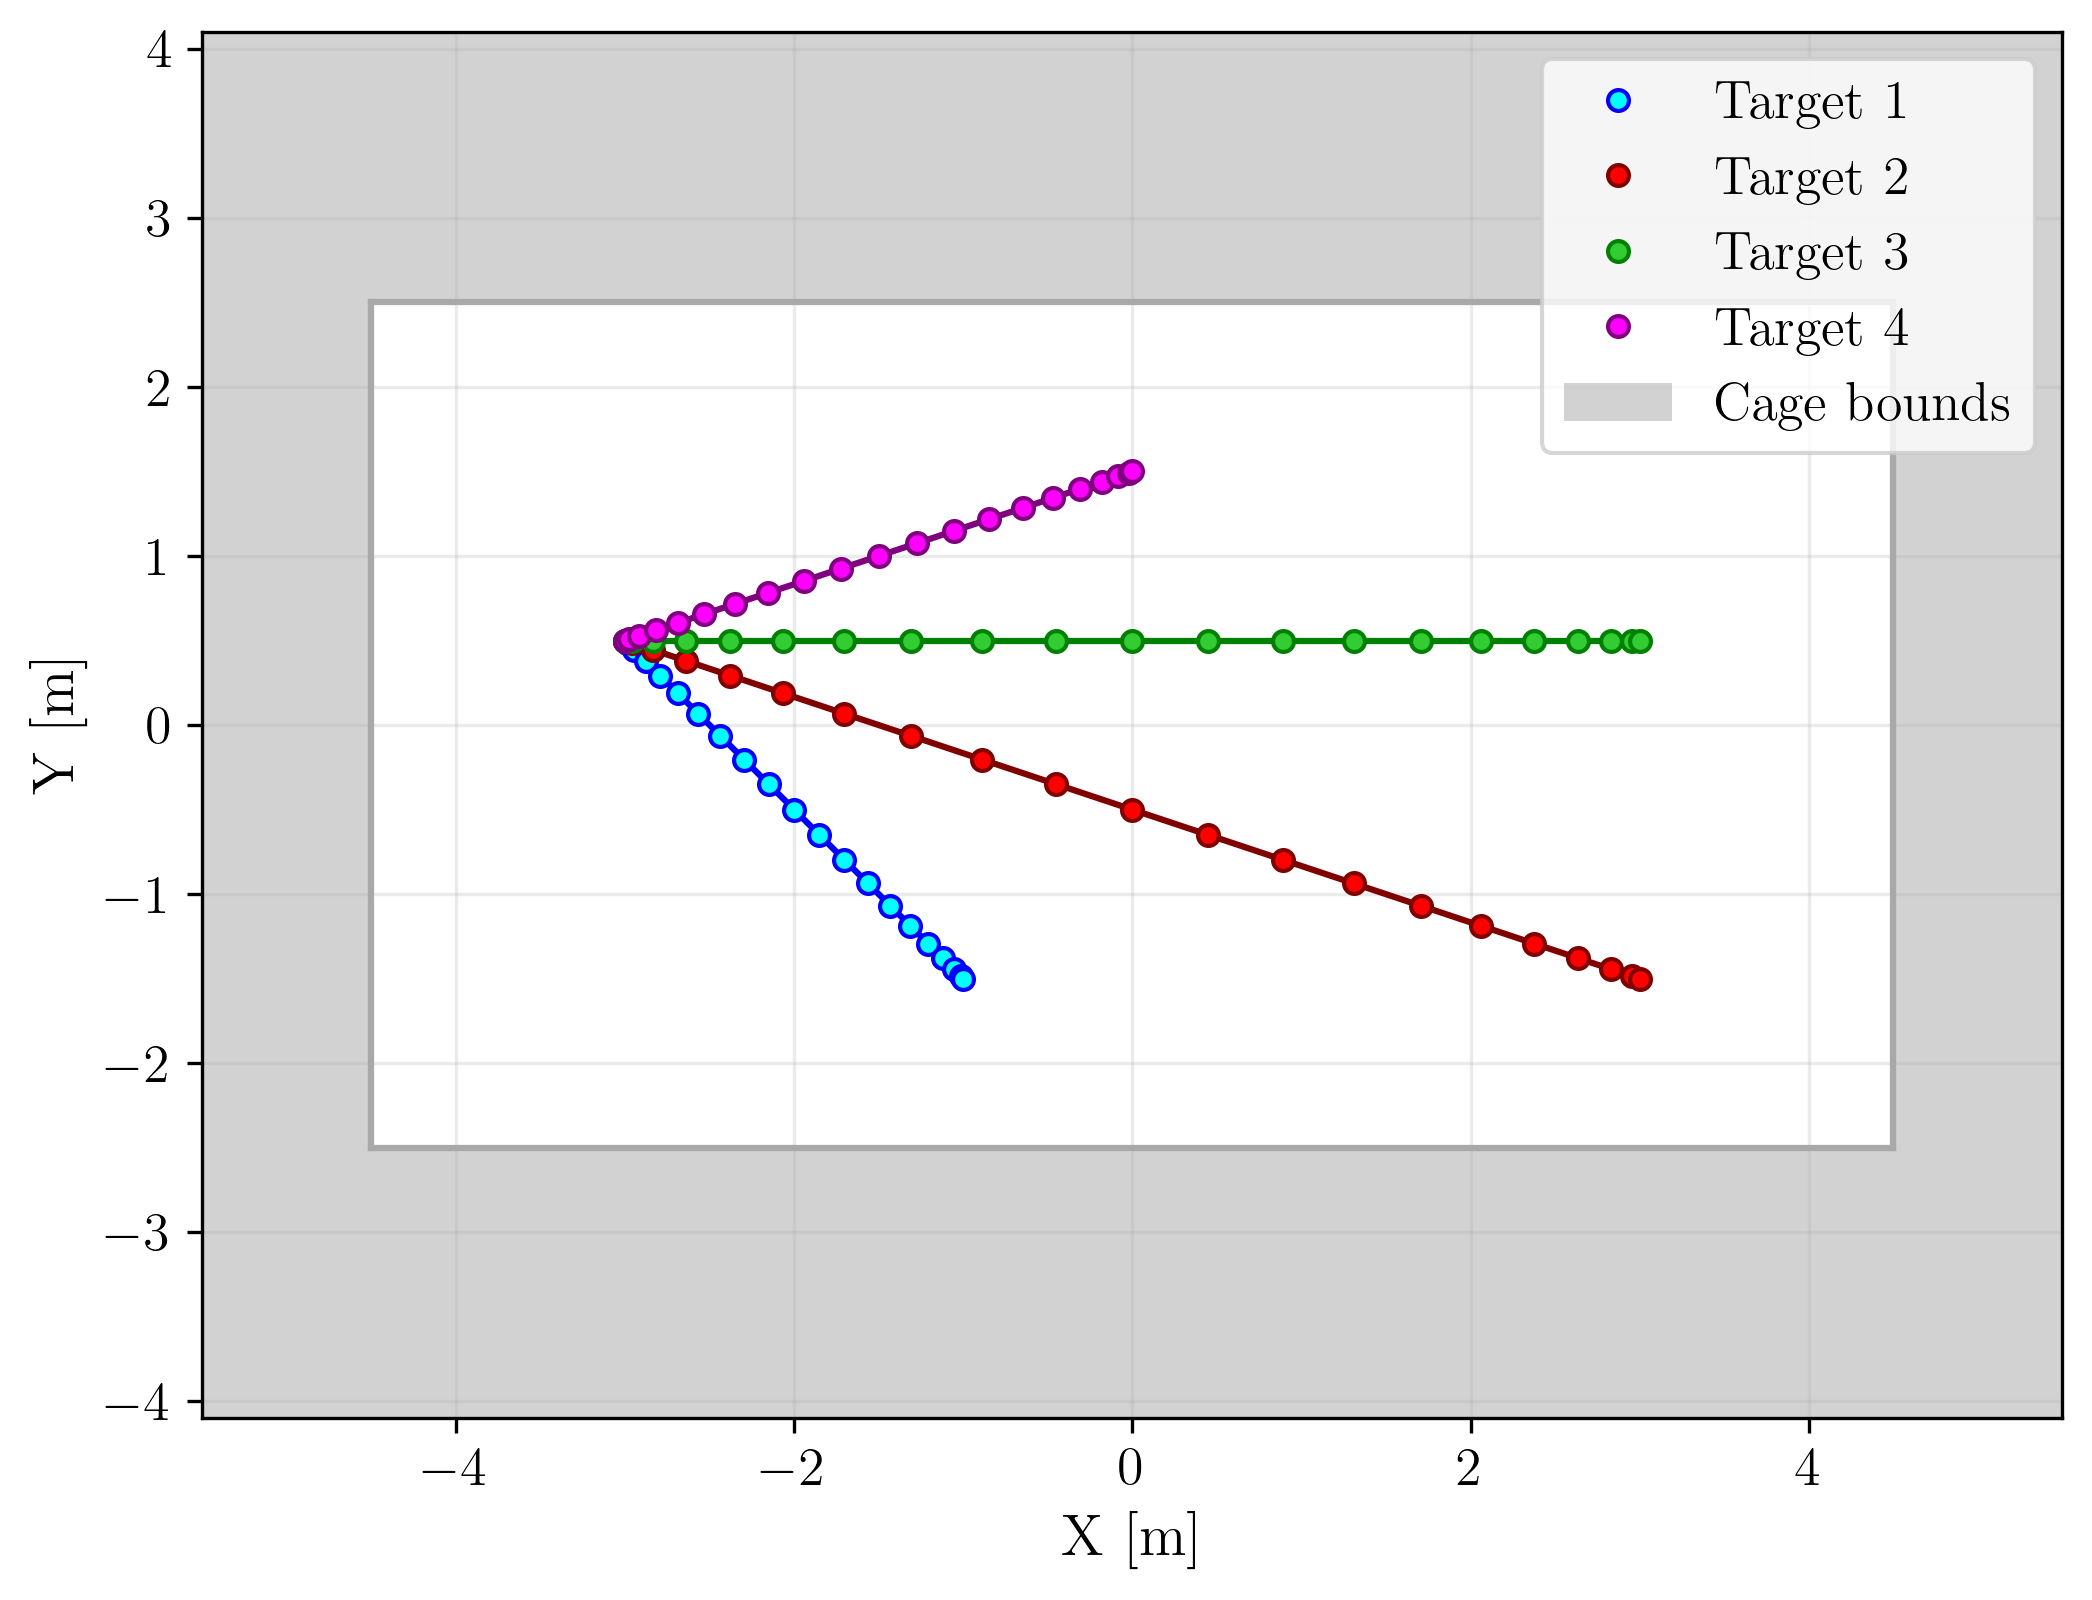

In [7]:
plot_parametric_optimal_trajectories(params, opt_solutions, opt_simulations)

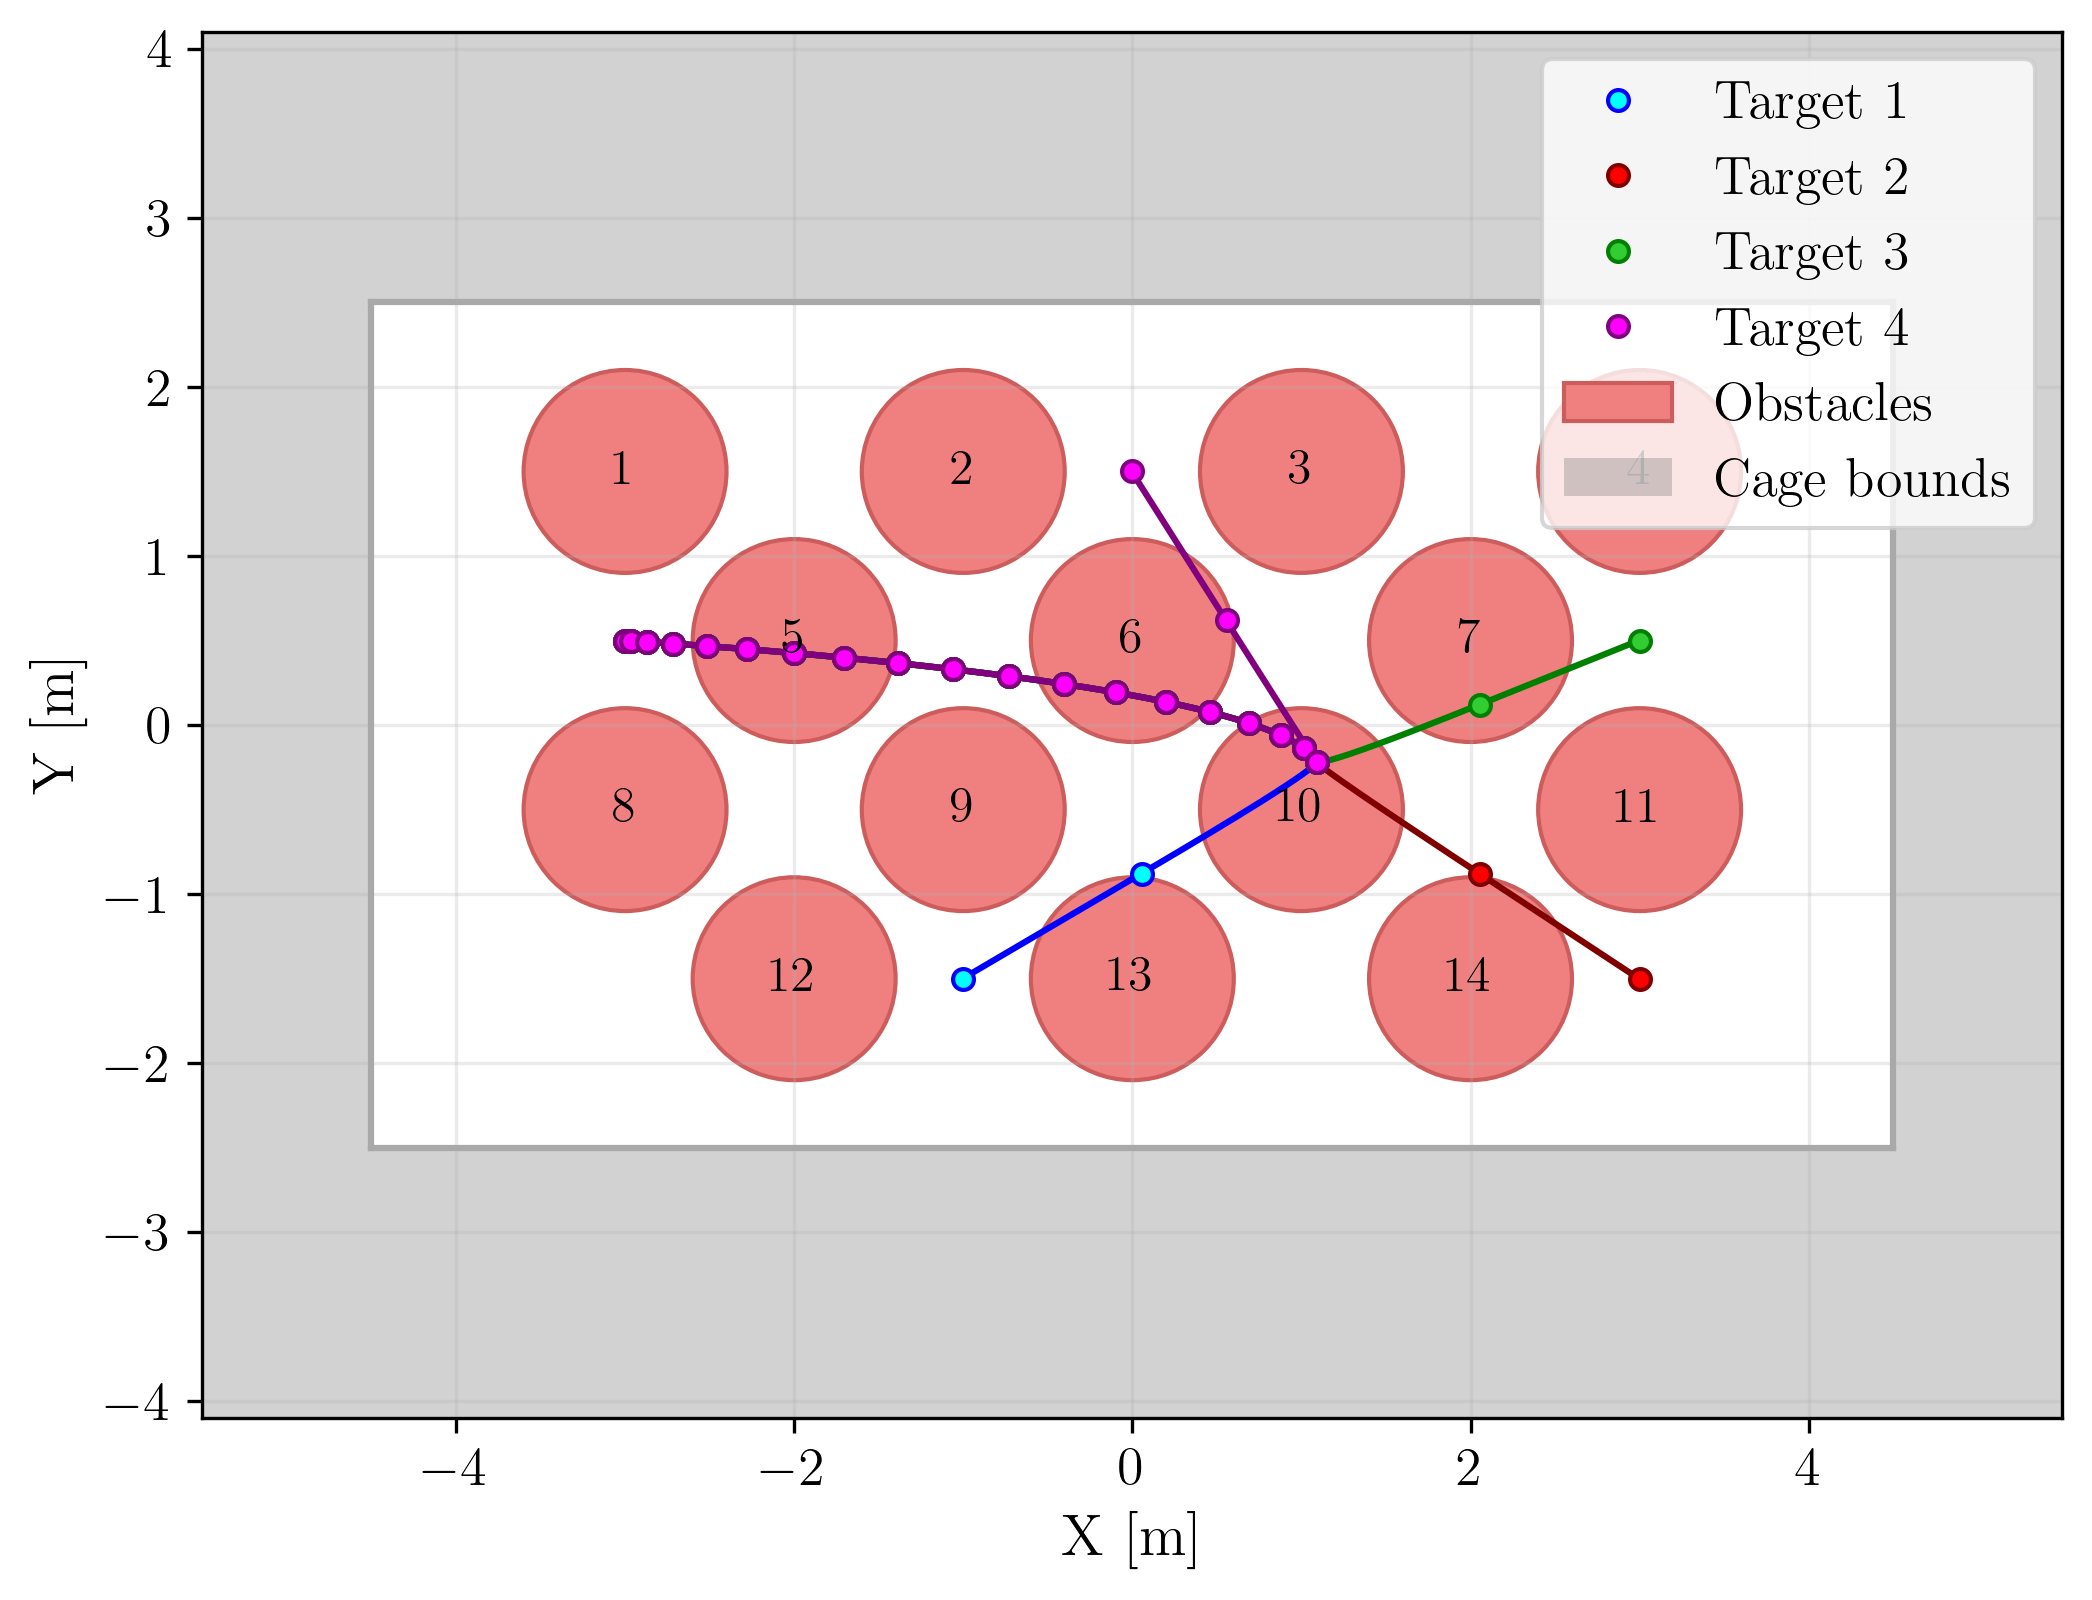

In [8]:
plot_parametric_ddto_trajectories(params, branch_solutions, branch_simulations)

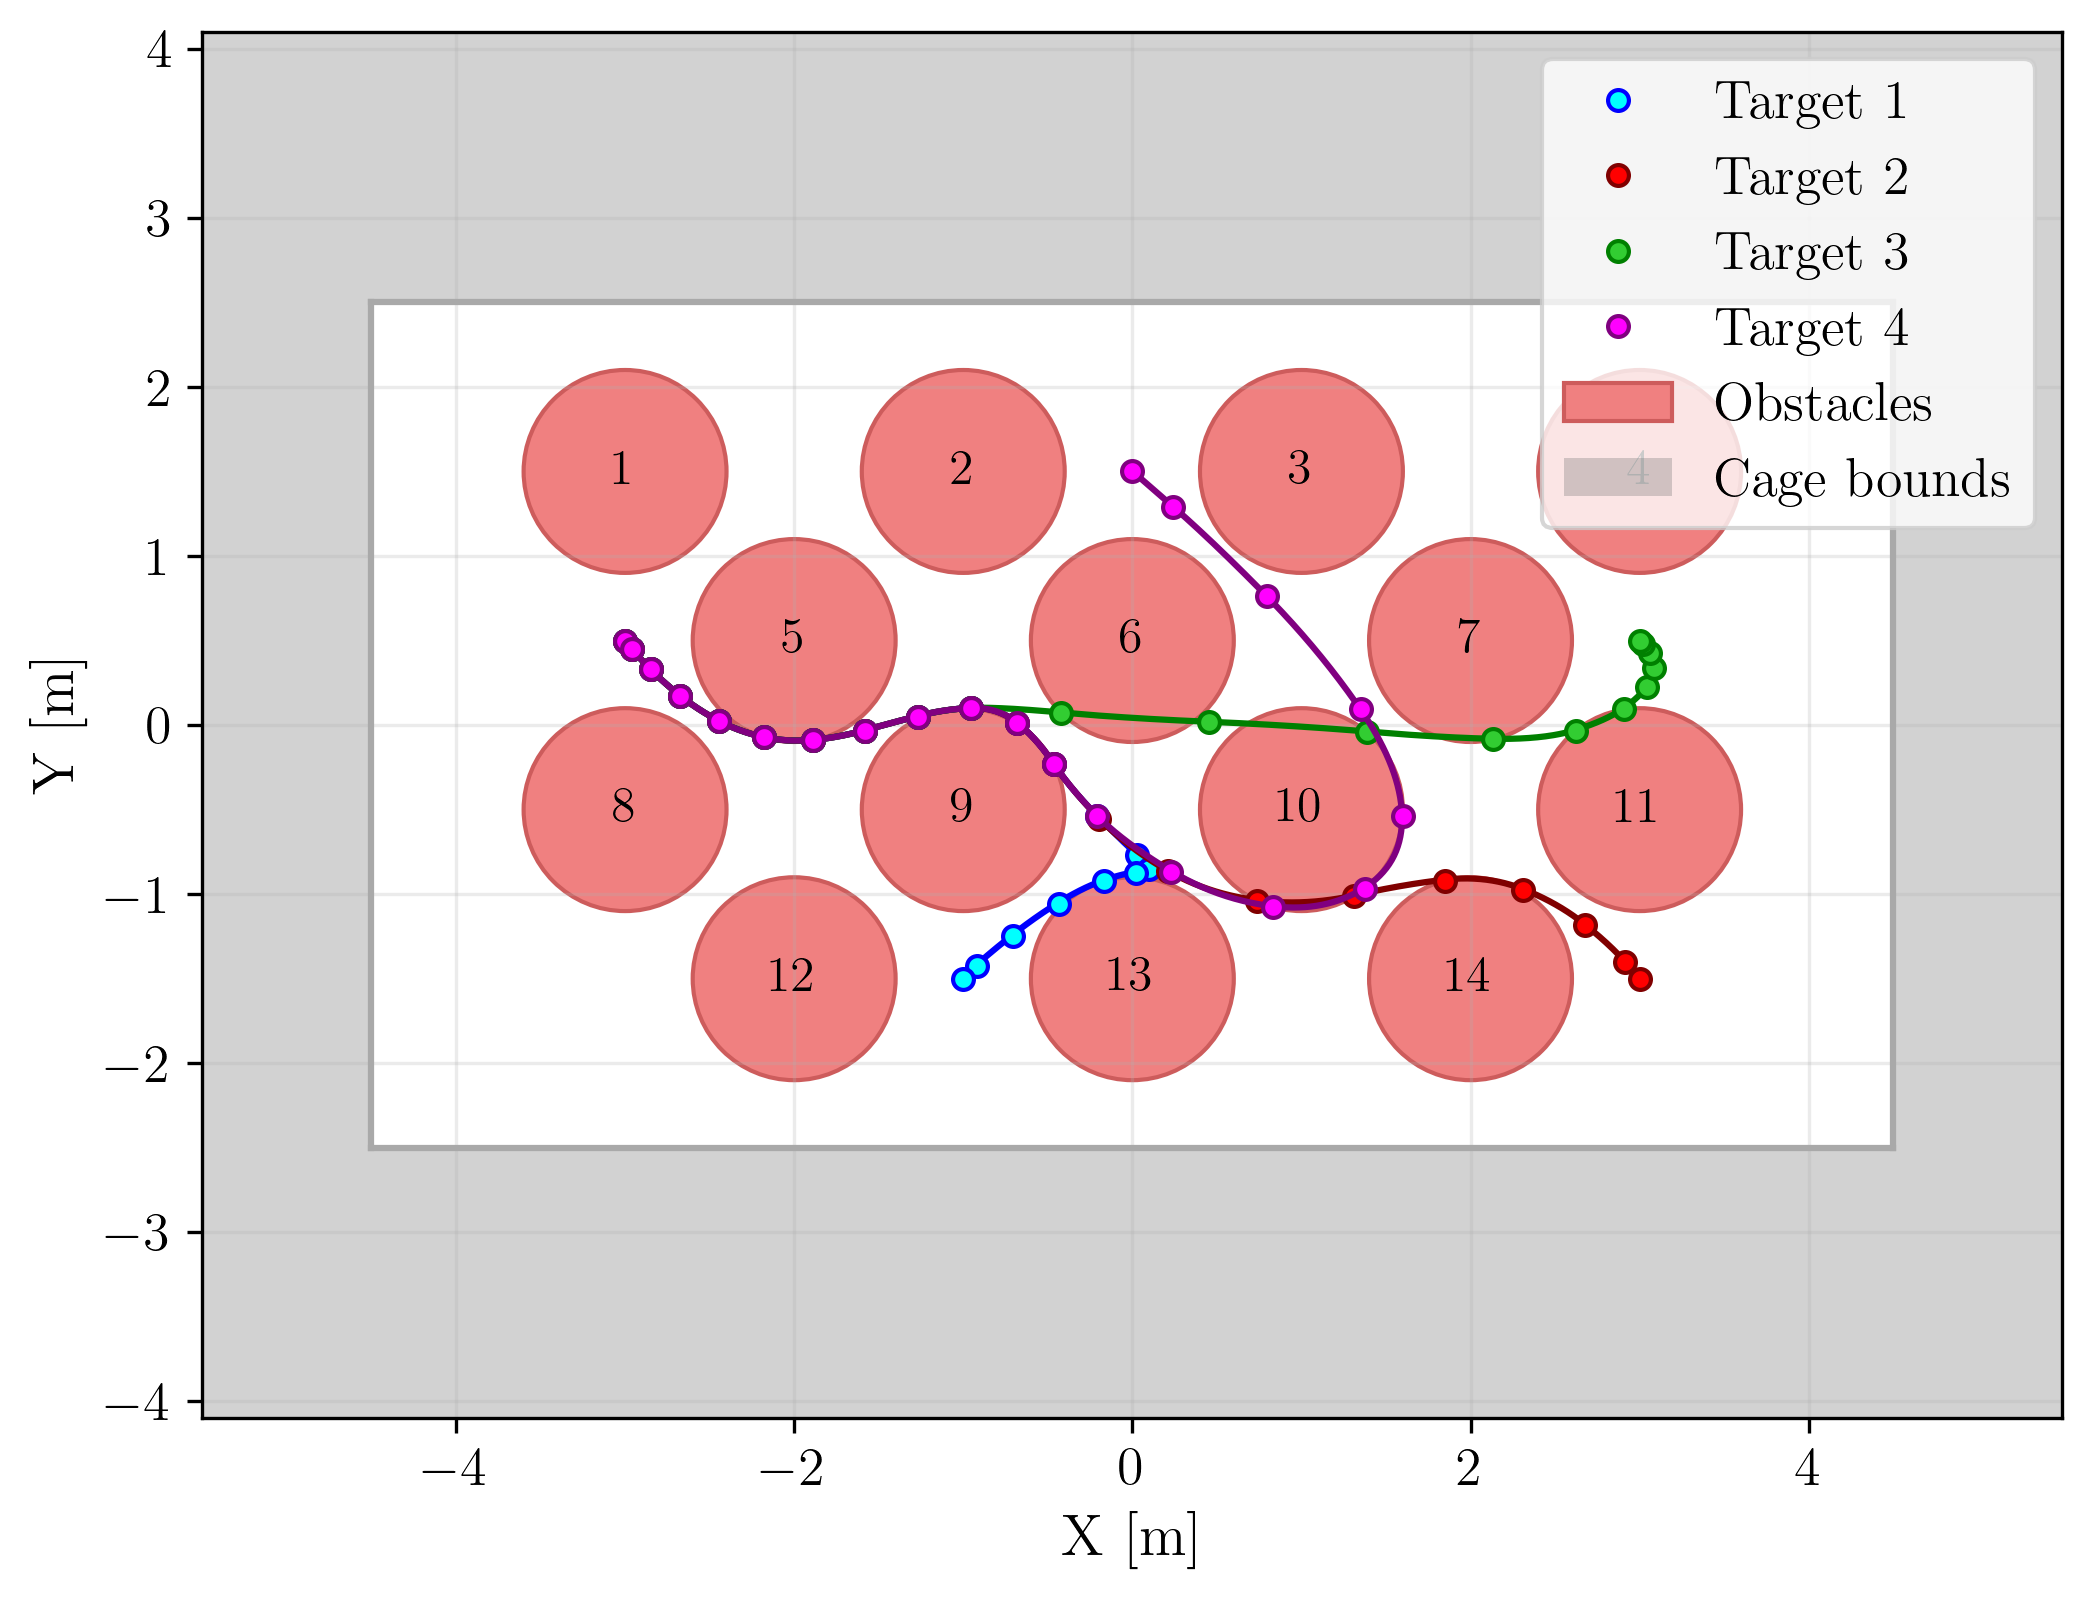

In [9]:
plot_parametric_ddto_trajectories(params, branchscp_solutions, branchscp_simulations)